In [1]:
# 1. 안정적인 얼굴 랜드마크 추출 라이브러리 설치
!pip install face_recognition

# 2. 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=8a05d432d725e0f62f733960bd9ae424f286db998d9e3ae25bfab2b93c0cdb66
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models
Mounted at /content/drive


In [13]:
import os
import cv2
import json
import numpy as np
import face_recognition
from tqdm import tqdm

# 1. 경로 설정
video_dirs = [
    "/content/drive/MyDrive/TEST_1/data/dfdc_train_part_1",
    "/content/drive/MyDrive/TEST_1/data/dfdc_train_part_2",
    "/content/drive/MyDrive/TEST_1/data/dfdc_train_part_3",
    "/content/drive/MyDrive/TEST_1/data/dfdc_train_part_4",
]
frame_root = "/content/drive/MyDrive/project23/processed_frames"
os.makedirs(frame_root, exist_ok=True)

# 2. 마스킹 함수
def apply_facial_mask(frame, img_size=224):
    h, w, _ = frame.shape
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    face_landmarks_list = face_recognition.face_landmarks(rgb_frame)
    mask = np.zeros((h, w), dtype=np.uint8)

    if face_landmarks_list:
        for face_landmarks in face_landmarks_list:
            line_thickness = max(2, int(w * 0.015))

            if 'chin' in face_landmarks:
                pts = np.array(face_landmarks['chin'], np.int32)
                cv2.polylines(mask, [pts], False, 255, line_thickness)
            if 'top_lip' in face_landmarks:
                pts = np.array(face_landmarks['top_lip'], np.int32)
                cv2.polylines(mask, [pts], True, 255, line_thickness)
            if 'bottom_lip' in face_landmarks:
                pts = np.array(face_landmarks['bottom_lip'], np.int32)
                cv2.polylines(mask, [pts], True, 255, line_thickness)

            masked_frame = cv2.bitwise_and(frame, frame, mask=mask)

            all_pts = []
            for feature in face_landmarks.values():
                all_pts.extend(feature)
            all_pts = np.array(all_pts)

            x_min, y_min = np.min(all_pts, axis=0)
            x_max, y_max = np.max(all_pts, axis=0)

            margin_x = int((x_max - x_min) * 0.2)
            margin_y = int((y_max - y_min) * 0.2)

            x_min = max(0, x_min - margin_x)
            x_max = min(w, x_max + margin_x)
            y_min = max(0, y_min - margin_y)
            y_max = min(h, y_max + margin_y)

            cropped_face = masked_frame[y_min:y_max, x_min:x_max]

            if cropped_face.size != 0:
                return cv2.resize(cropped_face, (img_size, img_size))

    return None


In [14]:
def extract_frames(cap, fps, start_sec, duration_sec=3, interval=8):
    start_frame = int(fps * start_sec)
    max_frames = int(fps * duration_sec)

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    frames = []
    idx = 0
    while idx < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % interval == 0:
            frames.append(frame)
        idx += 1

    return frames

# 4. 메인 루프
for video_dir in video_dirs:
    meta_path = os.path.join(video_dir, "metadata.json")

    if not os.path.exists(meta_path):
        print(f"경고: metadata.json 없음 → {video_dir} 스킵")
        continue

    with open(meta_path, "r") as f:
        meta = json.load(f)

    part_name = os.path.basename(video_dir)
    video_list = list(meta.keys())[:50]
    print(f"\n[{part_name}] 메타데이터 로드 완료. (총 {len(meta)}개 영상)")

    for video_name in tqdm(video_list, desc=f"{part_name}"):
        label = meta[video_name]["label"]
        video_path = os.path.join(video_dir, video_name)

        if not os.path.exists(video_path):
            tqdm.write(f"  영상 없음 스킵: {video_name}")
            continue

        save_dir = os.path.join(frame_root, label, part_name, video_name[:-4])
        os.makedirs(save_dir, exist_ok=True)

        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
        total_sec = total_frames / fps

        # 중간 3초 시도
        mid_start = max(0, (total_sec / 2) - 1.5)
        frames = extract_frames(cap, fps, start_sec=mid_start, duration_sec=3, interval=8)

        saved = 0
        for frame in frames:
            processed = apply_facial_mask(frame, img_size=224)
            if processed is not None:
                cv2.imwrite(f"{save_dir}/frame_{saved}.jpg", processed)
                saved += 1

        # fallback: 앞 3초
        if saved == 0:
            tqdm.write(f"  fallback → 앞 3초: {video_name}")
            frames = extract_frames(cap, fps, start_sec=0, duration_sec=3, interval=8)
            for frame in frames:
                processed = apply_facial_mask(frame, img_size=224)
                if processed is not None:
                    cv2.imwrite(f"{save_dir}/frame_{saved}.jpg", processed)
                    saved += 1

        cap.release()

    print(f"[{part_name}] 완료!")

print(f"\n전체 전처리 완료! 저장 경로: {frame_root}")


[dfdc_train_part_1] 메타데이터 로드 완료. (총 1699개 영상)


dfdc_train_part_1:   0%|          | 0/50 [00:17<?, ?it/s]

  fallback → 앞 3초: zumqqvixhu.mp4


dfdc_train_part_1:  14%|█▍        | 7/50 [02:39<13:15, 18.49s/it]

  fallback → 앞 3초: tguqyatciq.mp4


...

  fallback → 앞 3초: aczofflgti.mp4


dfdc_train_part_4:  92%|█████████▏| 46/50 [14:55<01:16, 19.02s/it]

  영상 없음 스킵: zzcrzuecap.mp4


dfdc_train_part_4: 100%|██████████| 50/50 [15:53<00:00, 19.08s/it]

[dfdc_train_part_4] 완료!

전체 전처리 완료! 저장 경로: /content/drive/MyDrive/project23/processed_frames


성공적으로 추출 및 마스킹된 이미지 총 개수: 1692


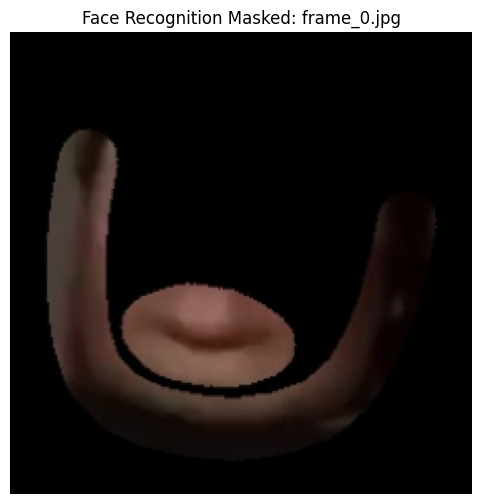

In [18]:
frame_list = glob.glob(f"{frame_root}/*/*/*/*.jpg")  # * 하나 추가
print(f"성공적으로 추출 및 마스킹된 이미지 총 개수: {len(frame_list)}")

if frame_list:
    img = Image.open(frame_list[0])
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Face Recognition Masked: {os.path.basename(frame_list[0])}")
    plt.axis("off")
    plt.show()
else:
    print("저장된 이미지가 없습니다.")

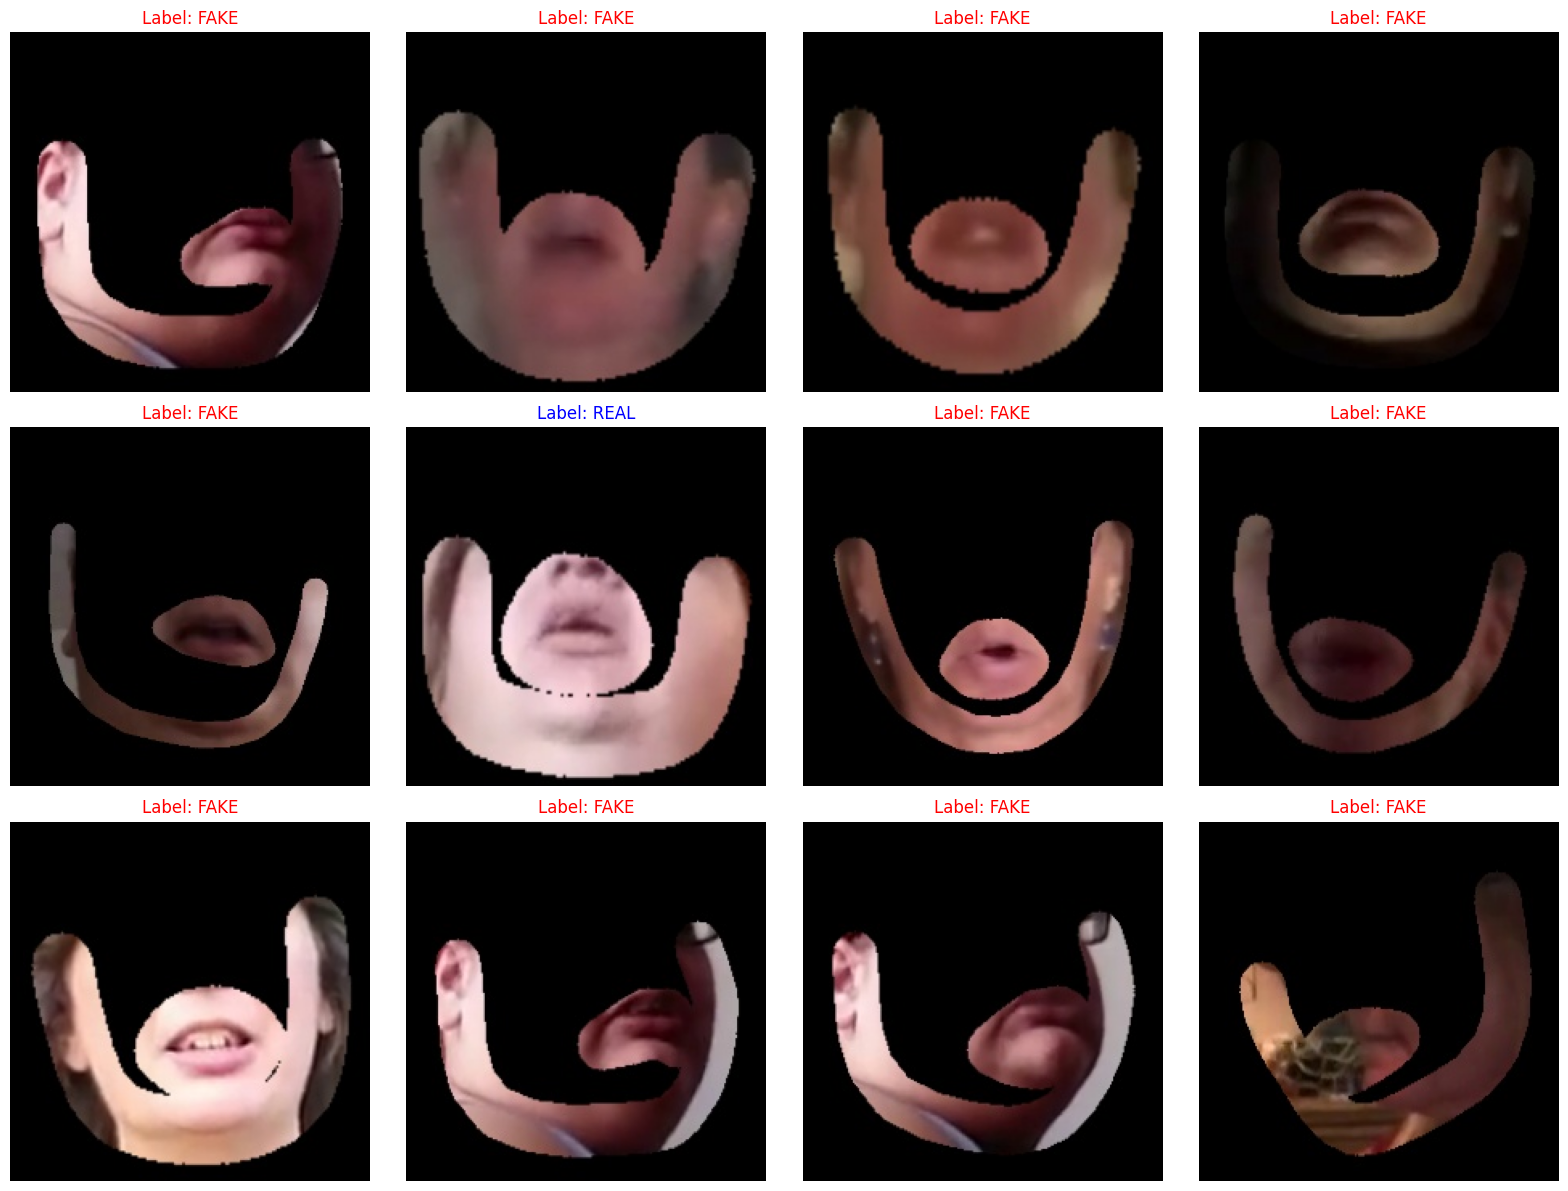

In [20]:
import random

def show_random_results(frame_root, num_images=12):
    all_frames = glob.glob(f"{frame_root}/*/*/*/*.jpg")  # * 하나 추가

    if not all_frames:
        print("시각화할 이미지가 없습니다. 전처리를 먼저 진행해주세요.")
        return

    num_images = min(num_images, len(all_frames))
    sample_frames = random.sample(all_frames, num_images)

    cols = 4
    rows = (num_images + cols - 1) // cols
    plt.figure(figsize=(16, rows * 4))

    for i, img_path in enumerate(sample_frames):
        parts = img_path.split('/')
        label = parts[-4]  # * 하나 늘었으니까 -3 → -4로 변경

        img = Image.open(img_path)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        title_obj = plt.title(f"Label: {label}")
        plt.setp(title_obj, color=('red' if label == 'FAKE' else 'blue'))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_results(frame_root, num_images=12)

In [24]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import glob
import os

# 1. 커스텀 데이터셋 클래스
class DeepfakeDataset(Dataset):
    def __init__(self, frame_root, transform=None):
        self.transform = transform
        self.data = []

        for label_name, label_idx in [("REAL", 0), ("FAKE", 1)]:
            frames = glob.glob(f"{frame_root}/{label_name}/*/*/**.jpg")
            for path in frames:
                self.data.append((path, label_idx))

        print(f"전체 이미지 수: {len(self.data)}")
        real_count = sum(1 for _, l in self.data if l == 0)
        fake_count = sum(1 for _, l in self.data if l == 1)
        print(f"  REAL: {real_count}장 | FAKE: {fake_count}장")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label


# 2. 전처리 & 증강 설정
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


# 3. 데이터셋 분할 (train 80% / val 20%)
full_dataset = DeepfakeDataset(frame_root, transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transform

# 4. 데이터로더
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"\ntrain: {len(train_dataset)}장 | val: {len(val_dataset)}장")
print(f"train 배치 수: {len(train_loader)} | val 배치 수: {len(val_loader)}")
print("데이터로더 준비 완료!")

전체 이미지 수: 1692
  REAL: 111장 | FAKE: 1581장

train: 1353장 | val: 339장
train 배치 수: 43 | val 배치 수: 11
데이터로더 준비 완료!


In [25]:
import random

class DeepfakeDataset(Dataset):
    def __init__(self, frame_root, transform=None):
        self.transform = transform
        self.data = []

        real_frames = glob.glob(f"{frame_root}/REAL/*/*/**.jpg")
        fake_frames = glob.glob(f"{frame_root}/FAKE/*/*/**.jpg")

        print(f"원본 REAL: {len(real_frames)}장 | FAKE: {len(fake_frames)}장")

        # 언더샘플링: 적은 쪽 기준으로 맞추기
        min_count = min(len(real_frames), len(fake_frames))
        real_frames = random.sample(real_frames, min_count)
        fake_frames = random.sample(fake_frames, min_count)

        for path in real_frames:
            self.data.append((path, 0))
        for path in fake_frames:
            self.data.append((path, 1))

        random.shuffle(self.data)

        print(f"언더샘플링 후 REAL: {min_count}장 | FAKE: {min_count}장")
        print(f"전체 이미지 수: {len(self.data)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


# 나머지는 동일
full_dataset = DeepfakeDataset(frame_root, transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"\ntrain: {len(train_dataset)}장 | val: {len(val_dataset)}장")
print(f"train 배치 수: {len(train_loader)} | val 배치 수: {len(val_loader)}")
print("데이터로더 준비 완료!")

원본 REAL: 111장 | FAKE: 1581장
언더샘플링 후 REAL: 111장 | FAKE: 111장
전체 이미지 수: 222

train: 177장 | val: 45장
train 배치 수: 6 | val 배치 수: 2
데이터로더 준비 완료!


In [28]:
import torch
import torch.nn as nn
from torchvision import models

# 1. 디바이스 설정 (GPU 있으면 GPU 사용)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

# 2. ResNet50 모델 불러오기 (사전학습 가중치 사용)
model = models.resnet50(pretrained=True)

# 3. 마지막 레이어를 이진분류(REAL/FAKE)용으로 교체
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

# 4. 손실함수 & 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 5. 학습 함수
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in tqdm(loader, desc="train"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


# 6. 검증 함수
def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="val"):
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total


# 7. 학습 루프 (10 에폭)
num_epochs = 10
best_val_acc = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)

    print(f"[Epoch {epoch+1}/{num_epochs}] "
          f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
          f"val loss: {val_loss:.4f} | val acc: {val_acc:.4f}")

    # 가장 좋은 모델 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/TEST_1/resnet_best.pth")
        print(f"  ✓ 최고 모델 저장! val acc: {val_acc:.4f}")

print(f"\nResNet 학습 완료! 최고 val acc: {best_val_acc:.4f}")

사용 디바이스: cuda


val: 100%|██████████| 2/2 [00:00<00:00,  4.08it/s]


[Epoch 1/10] train loss: 0.5123 | train acc: 0.7288 | val loss: 0.5051 | val acc: 0.7333
  ✓ 최고 모델 저장! val acc: 0.7333


val: 100%|██████████| 2/2 [00:00<00:00,  4.25it/s]


[Epoch 2/10] train loss: 0.1820 | train acc: 0.9492 | val loss: 0.4944 | val acc: 0.7778
  ✓ 최고 모델 저장! val acc: 0.7778


...

[Epoch 8/10] train loss: 0.0175 | train acc: 0.9944 | val loss: 0.5592 | val acc: 0.8889


val: 100%|██████████| 2/2 [00:00<00:00,  4.42it/s]


[Epoch 9/10] train loss: 0.0044 | train acc: 1.0000 | val loss: 0.6739 | val acc: 0.8667


val: 100%|██████████| 2/2 [00:00<00:00,  3.54it/s]

[Epoch 10/10] train loss: 0.0107 | train acc: 0.9944 | val loss: 0.7072 | val acc: 0.8889

ResNet 학습 완료! 최고 val acc: 0.9111


In [29]:
import torch
import torch.nn as nn
from torchvision import models

# 1. ViT 모델 불러오기
vit_model = models.vit_b_16(pretrained=True)

# 2. 마지막 레이어 이진분류용으로 교체
vit_model.heads = nn.Linear(vit_model.heads[0].in_features, 2)
vit_model = vit_model.to(device)

# 3. 손실함수 & 옵티마이저
vit_criterion = nn.CrossEntropyLoss()
vit_optimizer = torch.optim.Adam(vit_model.parameters(), lr=1e-4)

# 4. 학습 루프 (10 에폭)
best_vit_val_acc = 0

for epoch in range(num_epochs):
    vit_model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"ViT train {epoch+1}"):
        imgs, labels = imgs.to(device), labels.to(device)

        vit_optimizer.zero_grad()
        outputs = vit_model(imgs)
        loss = vit_criterion(outputs, labels)
        loss.backward()
        vit_optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # 검증
    vit_model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"ViT val {epoch+1}"):
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = vit_model(imgs)
            loss = vit_criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_acc = correct / total

    print(f"[Epoch {epoch+1}/{num_epochs}] "
          f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
          f"val loss: {val_loss:.4f} | val acc: {val_acc:.4f}")

    # 가장 좋은 모델 저장
    if val_acc > best_vit_val_acc:
        best_vit_val_acc = val_acc
        torch.save(vit_model.state_dict(), "/content/drive/MyDrive/TEST_1/vit_best.pth")
        print(f"  ✓ 최고 ViT 모델 저장! val acc: {val_acc:.4f}")

print(f"\nViT 학습 완료! 최고 val acc: {best_vit_val_acc:.4f}")

ViT val 1: 100%|██████████| 2/2 [00:00<00:00,  2.39it/s]


[Epoch 1/10] train loss: 0.7719 | train acc: 0.5537 | val loss: 0.7185 | val acc: 0.4667
  ✓ 최고 ViT 모델 저장! val acc: 0.4667


ViT val 2: 100%|██████████| 2/2 [00:00<00:00,  2.02it/s]


[Epoch 2/10] train loss: 0.5982 | train acc: 0.6554 | val loss: 0.5766 | val acc: 0.6889
  ✓ 최고 ViT 모델 저장! val acc: 0.6889


ViT val 3: 100%|██████████| 2/2 [00:00<00:00,  2.43it/s]


...

[Epoch 8/10] train loss: 0.0730 | train acc: 0.9661 | val loss: 0.3624 | val acc: 0.8889
  ✓ 최고 ViT 모델 저장! val acc: 0.8889


ViT val 9: 100%|██████████| 2/2 [00:00<00:00,  2.28it/s]


[Epoch 9/10] train loss: 0.0627 | train acc: 0.9661 | val loss: 0.8345 | val acc: 0.8444


ViT val 10: 100%|██████████| 2/2 [00:11<00:00,  5.62s/it]

[Epoch 10/10] train loss: 0.0378 | train acc: 0.9774 | val loss: 0.3810 | val acc: 0.8667

ViT 학습 완료! 최고 val acc: 0.8889


In [30]:
# 1. 저장된 모델 불러오기
resnet_model = models.resnet50(pretrained=False)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 2)
resnet_model.load_state_dict(torch.load("/content/drive/MyDrive/TEST_1/resnet_best.pth"))
resnet_model = resnet_model.to(device)
resnet_model.eval()

vit_model = models.vit_b_16(pretrained=False)
vit_model.heads = nn.Linear(vit_model.heads[0].in_features, 2)
vit_model.load_state_dict(torch.load("/content/drive/MyDrive/TEST_1/vit_best.pth"))
vit_model = vit_model.to(device)
vit_model.eval()

# 2. 단일 영상 판정 함수
def predict_video(video_path, threshold=0.8):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    total_sec = total_frames / fps

    # 중앙 3초 구간 추출 (초당 4장 = 총 12장)
    mid_start = max(0, (total_sec / 2) - 1.5)
    frames = extract_frames(cap, fps, start_sec=mid_start, duration_sec=3, interval=int(fps/4))
    cap.release()

    if not frames:
        print("프레임 추출 실패")
        return None

    # 3. 프레임별 전처리
    fake_probs = []

    for frame in frames:
        processed = apply_facial_mask(frame, img_size=224)
        if processed is None:
            continue

        img = Image.fromarray(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
        img_tensor = val_transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            # ResNet 확률
            resnet_out = torch.softmax(resnet_model(img_tensor), dim=1)
            resnet_fake_prob = resnet_out[0][1].item()

            # ViT 확률
            vit_out = torch.softmax(vit_model(img_tensor), dim=1)
            vit_fake_prob = vit_out[0][1].item()

            # 앙상블 (평균)
            avg_fake_prob = (resnet_fake_prob + vit_fake_prob) / 2
            fake_probs.append(avg_fake_prob)

    if not fake_probs:
        print("얼굴 감지 실패")
        return None

    # 4. 판정 로직
    avg_prob = sum(fake_probs) / len(fake_probs)
    high_prob_ratio = sum(1 for p in fake_probs if p >= threshold) / len(fake_probs)

    is_fake = high_prob_ratio >= 0.5  # 절반 이상 프레임이 임계값 넘으면 FAKE

    print(f"\n===== 판정 결과 =====")
    print(f"분석 프레임 수: {len(fake_probs)}장")
    print(f"평균 FAKE 확률: {avg_prob:.4f}")
    print(f"임계값({threshold}) 초과 프레임 비율: {high_prob_ratio:.4f}")
    print(f"최종 판정: {'🔴 FAKE' if is_fake else '🟢 REAL'}")

    return {
        "is_fake": is_fake,
        "avg_prob": avg_prob,
        "high_prob_ratio": high_prob_ratio,
        "frame_probs": fake_probs
    }


# 5. 테스트 실행
test_video = "/content/drive/MyDrive/TEST_1/data/dfdc_train_part_0/aaqaifqrwn.mp4"
result = predict_video(test_video, threshold=0.8)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



===== 판정 결과 =====
분석 프레임 수: 13장
평균 FAKE 확률: 0.9839
임계값(0.8) 초과 프레임 비율: 1.0000
최종 판정: 🔴 FAKE


In [34]:
# part_0 메타데이터 불러오기
meta_path = "/content/drive/MyDrive/TEST_1/data/dfdc_train_part_0/metadata.json"
with open(meta_path, "r") as f:
    meta_test = json.load(f)

print(meta_test["aaqaifqrwn.mp4"]["label"])

FAKE


In [35]:
# part_0 메타데이터에서 REAL 영상 찾기
meta_path = "/content/drive/MyDrive/TEST_1/data/dfdc_train_part_0/metadata.json"
with open(meta_path, "r") as f:
    meta_test = json.load(f)

# REAL 영상 목록 찾기
real_videos = [name for name, info in meta_test.items() if info["label"] == "REAL"]
print(f"REAL 영상 수: {len(real_videos)}")
print(f"테스트할 영상: {real_videos[0]}")

# 첫 번째 REAL 영상으로 테스트
test_video = f"/content/drive/MyDrive/TEST_1/data/dfdc_train_part_0/{real_videos[0]}"
result = predict_video(test_video, threshold=0.8)

REAL 영상 수: 86
테스트할 영상: vpmyeepbep.mp4

===== 판정 결과 =====
분석 프레임 수: 8장
평균 FAKE 확률: 0.9971
임계값(0.8) 초과 프레임 비율: 1.0000
최종 판정: 🔴 FAKE
